# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [ ]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

In [27]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [28]:
#Q1

# Call Time.now() exactly once
now = Time.now()

# Print UTC
print("Current UTC:", now.utc.isot)

# Print IIT Kanpur civil time
print("IIT Kanpur time:", format_iitk(now))

Current UTC: 2026-09-06T14:21:18.148
IIT Kanpur time: 2026-09-06 19:51:18 IST


Two separate Time.now() calls need not describe exactly the same instant because some amount of time, however small, passes between the two calls.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [29]:
#Q2
# Create the quantities
height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

# Convert them
height_km = height.to(u.km)
frequency_THz = wavelength.to(u.THz, equivalencies=u.spectral())
uncertainty_arcsec = uncertainty.to(u.arcsec)
cadence_hours = cadence.to(u.hour)
wavelength_cm = frequency.to(u.cm, equivalencies=u.spectral())

# Print original and converted values
print("GTC height:", height, "=", height_km)
print("Wavelength:", wavelength, "=", frequency_THz)
print("Coordinate uncertainty:", uncertainty, "=", uncertainty_arcsec)
print("Cadence:", cadence, "=", cadence_hours)
print("Radio frequency:", frequency, "=", wavelength_cm)

GTC height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Radio frequency: 1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [30]:
#Q3

planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.isot)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour

print("Later UTC:", later.utc.isot)
print("Later IIT Kanpur:", format_iitk(later))

ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
round_trip = Time(ist_datetime)

difference = abs((round_trip - planning_start).to_value(u.s))

print("Round-trip difference:", difference, "seconds")
print("Less than one microsecond:", difference < 1e-6)

UTC: 2026-08-30T12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30T14:15:00.000
Later IIT Kanpur: 2026-08-30 19:45:00 IST
Round-trip difference: 0.0 seconds
Less than one microsecond: True


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [31]:
#Q4
ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(ra=ra, dec=dec, frame="icrs")

print("RA (deg):", frb_icrs.ra.deg)
print("Dec (deg):", frb_icrs.dec.deg)

print("RA (hms):", frb_icrs.ra.to_string(unit=u.hourangle, sep=":", pad=True))
print("Dec (dms):", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True))

ra_expected = 347.2704120833
dec_expected = 48.7066410556

print("RA verified:", abs(frb_icrs.ra.deg - ra_expected) < 1e-8)
print("Dec verified:", abs(frb_icrs.dec.deg - dec_expected) < 1e-8)

RA (deg): 347.27041208333327
Dec (deg): 48.70664105555556
RA (hms): 23:09:04.8989
Dec (dms): 48:42:23.9078
RA verified: True
Dec verified: True


RA (Right Ascension) is the celestial equivalent of longitude, its commonly used in hours because the sky behaves like a giant 24-hour clock due to earth rotation. Declination is an angular distance from the celestial equator, so it is expressed in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [32]:
#Q5

# Transform ICRS → Galactic
frb_galactic = frb_icrs.galactic

print("Galactic longitude l:", frb_galactic.l.deg)
print("Galactic latitude b:", frb_galactic.b.deg)

# Transform Galactic → ICRS
frb_icrs_back = frb_galactic.icrs

# Calculate round-trip separation
separation = frb_icrs.separation(frb_icrs_back)

print("Round-trip separation (microarcseconds):",
      separation.to(u.microarcsecond))

Galactic longitude l: 106.06496077332801
Galactic latitude b: -10.784176285402493
Round-trip separation (microarcseconds): 0.000310733 uarcsec


The tiny non-zero round-trip separation is due to floating-point numerical precision and rounding during the coordinate transformations. It is not a real change in the FRB's position; mathematically, transforming ICRS → Galactic → ICRS should return the original coordinates.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [33]:
#Q6
from astropy.coordinates import BarycentricTrueEcliptic

# Transform ICRS → Barycentric True Ecliptic (J2000)
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox="J2000")
)

# Print ecliptic coordinates
print("Ecliptic longitude λ (deg):", frb_ecliptic.lon.deg)
print("Ecliptic latitude β (deg):", frb_ecliptic.lat.deg)

# Verify valid ranges
print("λ valid:", 0 <= frb_ecliptic.lon.deg < 360)
print("β valid:", -90 <= frb_ecliptic.lat.deg <= 90)

# Transform back to ICRS
frb_icrs_back = frb_ecliptic.icrs

# Calculate round-trip separation
separation = frb_icrs.separation(frb_icrs_back)

print("Round-trip separation (microarcseconds):",
      separation.to(u.microarcsecond))

Ecliptic longitude λ (deg): 14.411187650340095
Ecliptic latitude β (deg): 48.34695843744783
λ valid: True
β valid: True
Round-trip separation (microarcseconds): 0 uarcsec


The ecliptic plane is basically the plane of Earth's orbit around the Sun.

Ecliptic longitude $\lambda$ tells us where around the ecliptic the object appears.
Ecliptic latitude $\beta$ tells us how far above or below the ecliptic plane the object appears.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [34]:
#Q7
# Constructing earlier position
earlier_position = SkyCoord(
    "23h09m04.9s",
    "+48d42m25.4s",
    frame="icrs"
)

# Convert to radians
ra1 = frb_icrs.ra.rad
dec1 = frb_icrs.dec.rad

ra2 = earlier_position.ra.rad
dec2 = earlier_position.dec.rad

# Great-circle formula
cos_delta_theta = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1)
)

# Clip to [-1, 1]
cos_delta_theta = np.clip(cos_delta_theta, -1.0, 1.0)

# Separation in radians
delta_theta = np.arccos(cos_delta_theta)

# Convert to arcsec
manual_arcsec = np.degrees(delta_theta) * 3600
manual_mas = manual_arcsec * 1000

# Astropy result
astropy_arcsec = frb_icrs.separation(earlier_position).to_value(u.arcsec)



# Difference
difference = abs(manual_arcsec - astropy_arcsec)

print("Manual separation:", manual_arcsec, "arcsec")
print("Manual separation:", manual_mas, "mas")

print("Astropy separation:", astropy_arcsec, "arcsec")
print("Difference:", difference, "arcsec")


Manual separation: 1.4922374490540065 arcsec
Manual separation: 1492.2374490540064 mas
Astropy separation: 1.492239726203449 arcsec
Difference: 2.277149442564408e-06 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [35]:
#Q8
from astropy.coordinates import EarthLocation
import astropy.units as u


# Define the GTC observing site

gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

# Recover and print the geodetic values
lon = gtc_location.lon.to(u.deg)
lat = gtc_location.lat.to(u.deg)
height = gtc_location.height.to(u.m)

print("GTC longitude:", lon)
print("GTC latitude:", lat)
print("GTC height:", height)

GTC longitude: -17d53m20.4s
GTC latitude: 28d45m28.8s
GTC height: 2395.9999999997463 m


The negative longitude means that the GTC is located 17.889° west of the Greenwich meridian

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [36]:
#Q9
from astropy.time import Time
import astropy.units as u

# Observation time
t = Time("2026-08-31T00:00:00Z")

# Apparent Local Sidereal Time at GTC
lst = t.sidereal_time("apparent", longitude=gtc_location.lon)

# Target RA
ra = frb_icrs.ra

# Hour angle
ha = (lst - ra).wrap_at(12 * u.hourangle)

print("UTC:", t.isot)
print("LST:", lst.to_string(unit=u.hour))
print("Hour angle:", ha.to_string(unit=u.hour))

UTC: 2026-08-31T00:00:00.000
LST: 21h25m12.29517887s
Hour angle: -1h43m52.60372113s


Target is east of the meridian

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [37]:
#Q10
# Calculate LST and hour angle for all 145 samples

lst_all = times.sidereal_time(
    "apparent",
    longitude=gtc_location.lon
)

ha_all = (lst_all - frb_icrs.ra).wrap_at(12 * u.hourangle)

# Finding the sample with the smallest absolute hour angle
nearest_idx = np.argmin(np.abs(ha_all))

print("Sample index:", nearest_idx)
print("UTC:", times[nearest_idx].isot)
print("IIT Kanpur time:", times[nearest_idx].to_datetime())
print("LST:", lst_all[nearest_idx].to_string(unit=u.hour))
print("Hour angle:", ha_all[nearest_idx].to_string(unit=u.hour))

Sample index: 82
UTC: 2026-08-31T01:40:00.000
IIT Kanpur time: 2026-08-31 01:40:00
LST: 23h05m28.72210035s
Hour angle: -0h03m36.17679965s


The result is a sampled approximation because the hour angle is calculated only at the 145 given sample times. The actual meridian transit occurs when the hour angle is exactly zero, which may occur between two sampled times. Therefore, the sample with the smallest absolute hour angle is the nearest sampled transit, not necessarily the exact transit instant.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [38]:
#Q11
# GTC latitude and target declination
phi = gtc_location.lat
delta = frb_icrs.dec

# Analytic transit altitude
h_transit = 90 * u.deg - np.abs(phi - delta)

# Zenith distance
z_transit = 90 * u.deg - h_transit

print("Predicted transit altitude:", h_transit)
print("Predicted zenith distance:", z_transit)

# Transform target to AltAz for all grid times
altaz_frame = AltAz(
    obstime=times,
    location=gtc_location
)

frb_altaz = frb_icrs.transform_to(altaz_frame)

# Find largest sampled altitude
max_alt_idx = np.argmax(frb_altaz.alt)

max_alt = frb_altaz.alt[max_alt_idx]
max_z = frb_altaz.zen[max_alt_idx]

print("\nLargest sampled altitude:", max_alt)
print("Sample index:", max_alt_idx)
print("UTC:", times[max_alt_idx].isot)
print("Sampled zenith distance:", max_z)

print("\nAltitude difference:",
      (max_alt - h_transit).to(u.arcsec))
print("Zenith-distance difference:",
      (max_z - z_transit).to(u.arcsec))

Predicted transit altitude: 70d03m04.8922s
Predicted zenith distance: 19d56m55.1078s

Largest sampled altitude: 69d53m01.94324592s
Sample index: 82
UTC: 2026-08-31T01:40:00.000
Sampled zenith distance: 20d06m58.05675408s

Altitude difference: -602.949 arcsec
Zenith-distance difference: 602.949 arcsec


The minus sign for altitude means the sampled object is lower than predicted, while the plus sign for zenith distance means it is farther from the zenith than predicted.

## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [39]:
#Q12
# Indices from Q10: nearest transit
transit_idx = nearest_idx

# Find the samples closest to 2 hours before and after transit
before_idx = transit_idx - 12 #samples are 10 min apart, 2 hours = 120 min /10min = 12
after_idx = transit_idx + 12

# Latitude and declination in radians
phi = gtc_location.lat.to(u.rad).value
delta = frb_icrs.dec.to(u.rad).value

for label, idx in [
    ("2 hours before transit", before_idx),
    ("At transit", transit_idx),
    ("2 hours after transit", after_idx)
]:

    # Hour angle in radians
    H = ha_all[idx].to(u.rad).value

    # Altitude equation
    sin_h = (
        np.sin(phi) * np.sin(delta)
        + np.cos(phi) * np.cos(delta) * np.cos(H)
    )

    sin_h = np.clip(sin_h, -1, 1)

    h = np.arcsin(sin_h) * u.rad

    print("\n", label)
    print("Sample index:", idx)
    print("UTC:", times[idx].isot)
    print("Hour angle:", ha_all[idx].to_string(unit=u.hour))
    print("Calculated altitude:", h.to(u.deg))
    print("Astropy altitude:", frb_altaz.alt[idx])


 2 hours before transit
Sample index: 70
UTC: 2026-08-30T23:40:00.000
Hour angle: -2h03m55.88910448s
Calculated altitude: 59.032158349271114 deg
Astropy altitude: 58d46m54.28676984s

 At transit
Sample index: 82
UTC: 2026-08-31T01:40:00.000
Hour angle: -0h03m36.17679965s
Calculated altitude: 70.03935712992158 deg
Astropy altitude: 69d53m01.94324592s

 2 hours after transit
Sample index: 94
UTC: 2026-08-31T03:40:00.000
Hour angle: 1h56m43.53551704s
Calculated altitude: 60.06283863737094 deg
Astropy altitude: 60d09m44.51549183s


## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [40]:
#Q13
import numpy as np
import astropy.units as u

# Minimum altitude
h_min = 20 * u.deg

# Latitude and declination in radians
phi = gtc_location.lat.to(u.rad).value
delta = frb_icrs.dec.to(u.rad).value
hmin = h_min.to(u.rad).value

# Calculating cos(H0)
cos_H0 = (
    np.sin(hmin) - np.sin(phi) * np.sin(delta)
) / (
    np.cos(phi) * np.cos(delta)
)

# Avoid numerical problems
cos_H0 = np.clip(cos_H0, -1, 1)

# Calculating H0
H0_rad = np.arccos(cos_H0)

# Converting to degrees and sidereal hours
H0_deg = np.degrees(H0_rad)
H0_hours = H0_deg / 15

# Total time above 20 degrees
total_hours = 2 * H0_hours

# Count actual grid samples above 20 degrees
above_20 = frb_altaz.alt >= h_min
n_samples = np.count_nonzero(above_20)

print("H0:", H0_deg, "degrees")
print("H0:", H0_hours, "sidereal hours")
print("Total time above 20 degrees:", total_hours, "hours")
print("Number of grid samples above 20 degrees:", n_samples)

H0: 91.92747700350239 degrees
H0: 6.128498466900159 sidereal hours
Total time above 20 degrees: 12.256996933800318 hours
Number of grid samples above 20 degrees: 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [41]:
#Q14
import numpy as np
import astropy.units as u

# Transform FRB to AltAz at GTC
frb_gtc_altaz = frb_icrs.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

# Calculate target airmass
target_airmass = np.array(frb_gtc_altaz.secz, dtype=float) # airmass X ~ secz

# Replacing invalid values with NaN
target_airmass[
    (frb_gtc_altaz.alt <= 0 * u.deg) |
    (~np.isfinite(target_airmass)) |
    (target_airmass < 1)
] = np.nan

# Finite airmass range
finite_airmass = target_airmass[np.isfinite(target_airmass)]

print("Finite airmass range:",
      np.min(finite_airmass), "to", np.max(finite_airmass))

# Best airmass
best_idx = np.nanargmin(target_airmass)

print("Best airmass:", target_airmass[best_idx])
print("UTC:", times[best_idx].isot)

from zoneinfo import ZoneInfo

print("IST:",
      times[best_idx].to_datetime(
          timezone=ZoneInfo("Asia/Kolkata")
      ).strftime("%Y-%m-%d %H:%M:%S IST"))

# Number of samples with 1 <= X <= 2.5
safe_samples = (
    (target_airmass >= 1) &
    (target_airmass <= 2.5)
)

print("Samples with 1 <= X <= 2.5:",
      np.count_nonzero(safe_samples))

Finite airmass range: 1.0649655775500655 to 55.34987513096205
Best airmass: 1.0649655775500655
UTC: 2026-08-31T01:40:00.000
IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68


Airmass represents the relative path length through the Earth's atmosphere compared with observing the source at the zenith. It is approximately given by $(X=sec z)$, where $(z)$ is the zenith distance. An airmass of 1 corresponds to the zenith, while larger values indicate that the source is observed through more atmosphere. Below-horizon values must not be used because the source is not physically observable and the mathematical value of secz is not a meaningful observing airmass.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [42]:
#Q15
from astropy.coordinates import get_sun, get_body, AltAz
import numpy as np
import astropy.units as u

# Sun and Moon positions
sun = get_sun(times)
moon = get_body("moon", times, location=gtc_location)

# Convert Sun and Moon to Alt/Az at GTC
sun_altaz = sun.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

moon_altaz = moon.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

sun_altitude = sun_altaz.alt


moon_altitude = moon_altaz.alt


moon_airmass = moon_altaz.secz.value.astype(float)

# Keeping Moon airmass only when Moon is above horizon and 1 <= X <= 3
moon_airmass[
    (moon_altitude <= 0 * u.deg) |
    (~np.isfinite(moon_airmass)) |
    (moon_airmass < 1) |
    (moon_airmass > 3)
] = np.nan

# Moon-target separation
moon_target_sep = moon.separation(frb_icrs)

# Sun-Moon elongation
sun_moon_elongation = sun.separation(moon)

# Illuminated fraction
epsilon = sun_moon_elongation.to(u.rad).value
illuminated_fraction = (1 - np.cos(epsilon)) / 2

# Course sky-condition classification
classification = np.full(len(times), "Unknown", dtype=object)

# Check which samples have finite inputs
finite = (
    np.isfinite(moon_altitude.to_value(u.deg)) &
    np.isfinite(moon_target_sep.to_value(u.deg)) &
    np.isfinite(illuminated_fraction)
)

# Finite samples are Gray initially
classification[finite] = "Gray"

# Bright rule
bright = finite & (
    (
        (illuminated_fraction >= 0.70) &
        (moon_altitude > 10 * u.deg)
    ) |
    (moon_target_sep <= 45 * u.deg)
)

classification[bright] = "Bright"

# Dark rule
# Applied AFTER Bright, so Dark takes priority if both pass
dark = finite & (
    (moon_altitude < 0 * u.deg) |
    (
        (moon_target_sep >= 90 * u.deg) &
        (illuminated_fraction <= 0.25)
    )
)

classification[dark] = "Dark"


# Results
print("Sun altitude range:",
      sun_altitude.min(), "to", sun_altitude.max())

print("Moon altitude range:",
      moon_altitude.min(), "to", moon_altitude.max())

print("Moon airmass range:",
      np.nanmin(moon_airmass), "to", np.nanmax(moon_airmass))

print("Moon-target separation range:",
      moon_target_sep.min(), "to", moon_target_sep.max())

print("Illuminated fraction range:",
      illuminated_fraction.min(), "to", illuminated_fraction.max())


# Classification counts
unique, counts = np.unique(classification, return_counts=True)

print("\nSky-condition classification:")
for label, count in zip(unique, counts):
    print(f"{label}: {count}")

Sun altitude range: -52d32m57.36817221s to 70d06m18.5700086s
Moon altitude range: -56d08m31.1641664s to 69d42m31.12088371s
Moon airmass range: 1.0661648368108945 to 2.8951432130069588
Moon-target separation range: 44d33m56.44313934s to 46d22m56.06701774s
Illuminated fraction range: 0.8791968994517614 to 0.9406682728544431

Sky-condition classification:
Bright: 73
Dark: 67
Gray: 5


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [43]:
#Q16

def visibility(altitude, airmass, sun_altitude, moon_separation):

    # Validating that all inputs are one-dimensional and have equal length
    if not (
        altitude.ndim == 1 and
        airmass.ndim == 1 and
        sun_altitude.ndim == 1 and
        moon_separation.ndim == 1
    ):
        raise ValueError("All inputs must be one-dimensional arrays")

    if not (
        len(altitude) == len(airmass) ==
        len(sun_altitude) == len(moon_separation)
    ):
        raise ValueError("All inputs must have equal length")

    # Individual conditions
    condition_altitude = (altitude >= 20 * u.deg)

    condition_airmass = (
        np.isfinite(airmass) &
        (airmass >= 1) &
        (airmass <= 2.5)
    )

    condition_sun = (sun_altitude <= -18 * u.deg)

    condition_moon = (moon_separation >= 30 * u.deg)

    # Combined visibility condition
    result = (
        condition_altitude &
        condition_airmass &
        condition_sun &
        condition_moon
    )

    return result



target_airmass = frb_gtc_altaz.secz.value.astype(float)

# Ignore airmass when target is below horizon
target_airmass[
    (frb_gtc_altaz.alt <= 0 * u.deg) |
    (~np.isfinite(target_airmass))
] = np.nan

# Calling the function
visible = visibility(
    frb_gtc_altaz.alt,
    target_airmass,
    sun_altitude,
    moon_target_sep
)

# Independent condition counts
print("Altitude condition count:", np.count_nonzero(
    frb_gtc_altaz.alt >= 20 * u.deg
))

print("Airmass condition count:", np.count_nonzero(
    np.isfinite(target_airmass) &
    (target_airmass >= 1) &
    (target_airmass <= 2.5)
))

print("Sun condition count:", np.count_nonzero(
    sun_altitude <= -18 * u.deg
))

print("Moon separation condition count:", np.count_nonzero(
    moon_target_sep >= 30 * u.deg
))

# Combined count
print("Combined visible samples:", np.count_nonzero(visible))

# Overall yes/no answer
print("Any visible sample:", np.any(visible))

Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon separation condition count: 145
Combined visible samples: 51
Any visible sample: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [44]:
#Q17

from astropy.time import Time
from astropy.coordinates import AltAz, get_sun, get_body
import astropy.units as u
import numpy as np
from zoneinfo import ZoneInfo

# Two times to test
check_times = Time([
    times[nearest_idx].isot,          # nearest sampled transit from Q10
    "2026-08-31T06:00:00Z"
])

# Target altitude and airmass
target_altaz = frb_icrs.transform_to(
    AltAz(obstime=check_times, location=gtc_location)
)

target_altitude = target_altaz.alt
target_airmass = np.array(target_altaz.secz, dtype=float)

# Sun
sun = get_sun(check_times)
sun_altaz = sun.transform_to(
    AltAz(obstime=check_times, location=gtc_location)
)
sun_altitude = sun_altaz.alt

# Moon
moon = get_body("moon", check_times, location=gtc_location)

moon_separation = moon.separation(frb_icrs)

# Individual conditions
condition_altitude = target_altitude >= 20 * u.deg

condition_airmass = (
    np.isfinite(target_airmass) &
    (target_airmass >= 1) &
    (target_airmass <= 2.5)
)

condition_sun = sun_altitude <= -18 * u.deg

condition_moon = moon_separation >= 30 * u.deg

# Final visibility result
preferred_visibility = visibility(
    target_altitude,
    target_airmass,
    sun_altitude,
    moon_separation
)

# Print results
for i, label in enumerate(["Nearest sampled transit", "2026-08-31 06:00 UTC"]):

    ist = check_times[i].to_datetime(
        timezone=ZoneInfo("Asia/Kolkata")
    )

    print("\n" + label)
    print("-" * 45)

    print("UTC:", check_times[i].isot)
    print("IST:", ist.strftime("%Y-%m-%d %H:%M:%S IST"))
    print("Altitude:", target_altitude[i])
    print("Airmass:", target_airmass[i])
    print("Sun altitude:", sun_altitude[i])
    print("Moon separation:", moon_separation[i])

    print("\nConditions:")
    print("Altitude >= 20 deg:", condition_altitude[i])
    print("1 <= Airmass <= 2.5:", condition_airmass[i])
    print("Sun altitude <= -18 deg:", condition_sun[i])
    print("Moon separation >= 30 deg:", condition_moon[i])

    print("\nFinal preferred_visibility:", preferred_visibility[i])


Nearest sampled transit
---------------------------------------------
UTC: 2026-08-31T01:40:00.000
IST: 2026-08-31 07:10:00 IST
Altitude: 69d53m01.94324592s
Airmass: 1.0649655775500655
Sun altitude: -51d57m21.2803103s
Moon separation: 45d13m36.30275963s

Conditions:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: True
Moon separation >= 30 deg: True

Final preferred_visibility: True

2026-08-31 06:00 UTC
---------------------------------------------
UTC: 2026-08-31T06:00:00.000
IST: 2026-08-31 11:30:00 IST
Altitude: 37d59m10.36339034s
Airmass: 1.6247697405308272
Sun altitude: -11d16m54.28283981s
Moon separation: 44d41m53.31827813s

Conditions:
Altitude >= 20 deg: True
1 <= Airmass <= 2.5: True
Sun altitude <= -18 deg: False
Moon separation >= 30 deg: True

Final preferred_visibility: False


High altitude or meridian transit alone does not guarantee observability. Transit only indicates that the target is crossing the local meridian and is near its maximum altitude. Practical observability also depends on atmospheric path length (airmass), astronomical darkness, and the angular separation from the Moon. Therefore, all visibility conditions must be satisfied simultaneously.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

In [45]:
#Q18R
import numpy as np
import astropy.units as u
from astropy.time import Time

# Full-grid target quantities
frb_gtc_altaz = frb_icrs.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

target_airmass_full = np.array(
    frb_gtc_altaz.secz, dtype=float
)

# Full-grid Sun and Moon
sun = get_sun(times)

sun_altaz = sun.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

moon = get_body("moon", times, location=gtc_location)

moon_sep = moon.separation(frb_icrs)

# Full-grid visibility
preferred_visibility = visibility(
    frb_gtc_altaz.alt,
    target_airmass_full,
    sun_altaz.alt,
    moon_sep
)


def stitch_windows(times, visibility_state):

    windows = []
    start = None

    for i in range(len(times)):

        # Start of a new visibility window
        if visibility_state[i] and start is None:
            start = i

        # End of a visibility window #len(times)-1 stops python from going beyond the array
        if start is not None and (
            i == len(times) - 1 or not visibility_state[i + 1]
        ):
            windows.append((start, i))
            start = None

    return windows


# Find visibility windows
windows = stitch_windows(
    times,
    preferred_visibility
)


# Report each window
for start, end in windows:

    # Sample-centre duration
    duration = (times[end] - times[start]).to(u.hour)

    # Indices belonging to this window
    indices = np.arange(start, end + 1)

    # Best target airmass
    best_idx = indices[
        np.nanargmin(target_airmass_full[indices])
    ]

    # Midpoint sample
    midpoint_idx = (start + end) // 2

    print("\nVisibility window:")

    # UTC
    print(
        "UTC:",
        times[start].isot,
        "to",
        times[end].isot
    )

    # IIT Kanpur time
    start_ist = times[start].to_datetime(
        timezone=__import__("datetime").timezone(
            __import__("datetime").timedelta(hours=5, minutes=30)
        )
    )

    end_ist = times[end].to_datetime(
        timezone=__import__("datetime").timezone(
            __import__("datetime").timedelta(hours=5, minutes=30)
        )
    )

    print(
        "IIT Kanpur:",
        start_ist.strftime("%Y-%m-%d %H:%M:%S"),
        "to",
        end_ist.strftime("%Y-%m-%d %H:%M:%S")
    )

    print("Duration:", duration)

    print(
        "Best airmass:",
        target_airmass_full[best_idx]
    )

    print(
        "Midpoint UTC:",
        times[midpoint_idx].isot
    )

    print(
        "Midpoint Moon label:",
        classification[midpoint_idx]
    )


Visibility window:
UTC: 2026-08-30T21:00:00.000 to 2026-08-31T05:20:00.000
IIT Kanpur: 2026-08-31 02:30:00 to 2026-08-31 10:50:00
Duration: 8.333333333333332 h
Best airmass: 1.0649655775500655
Midpoint UTC: 2026-08-31T01:10:00.000
Midpoint Moon label: Bright


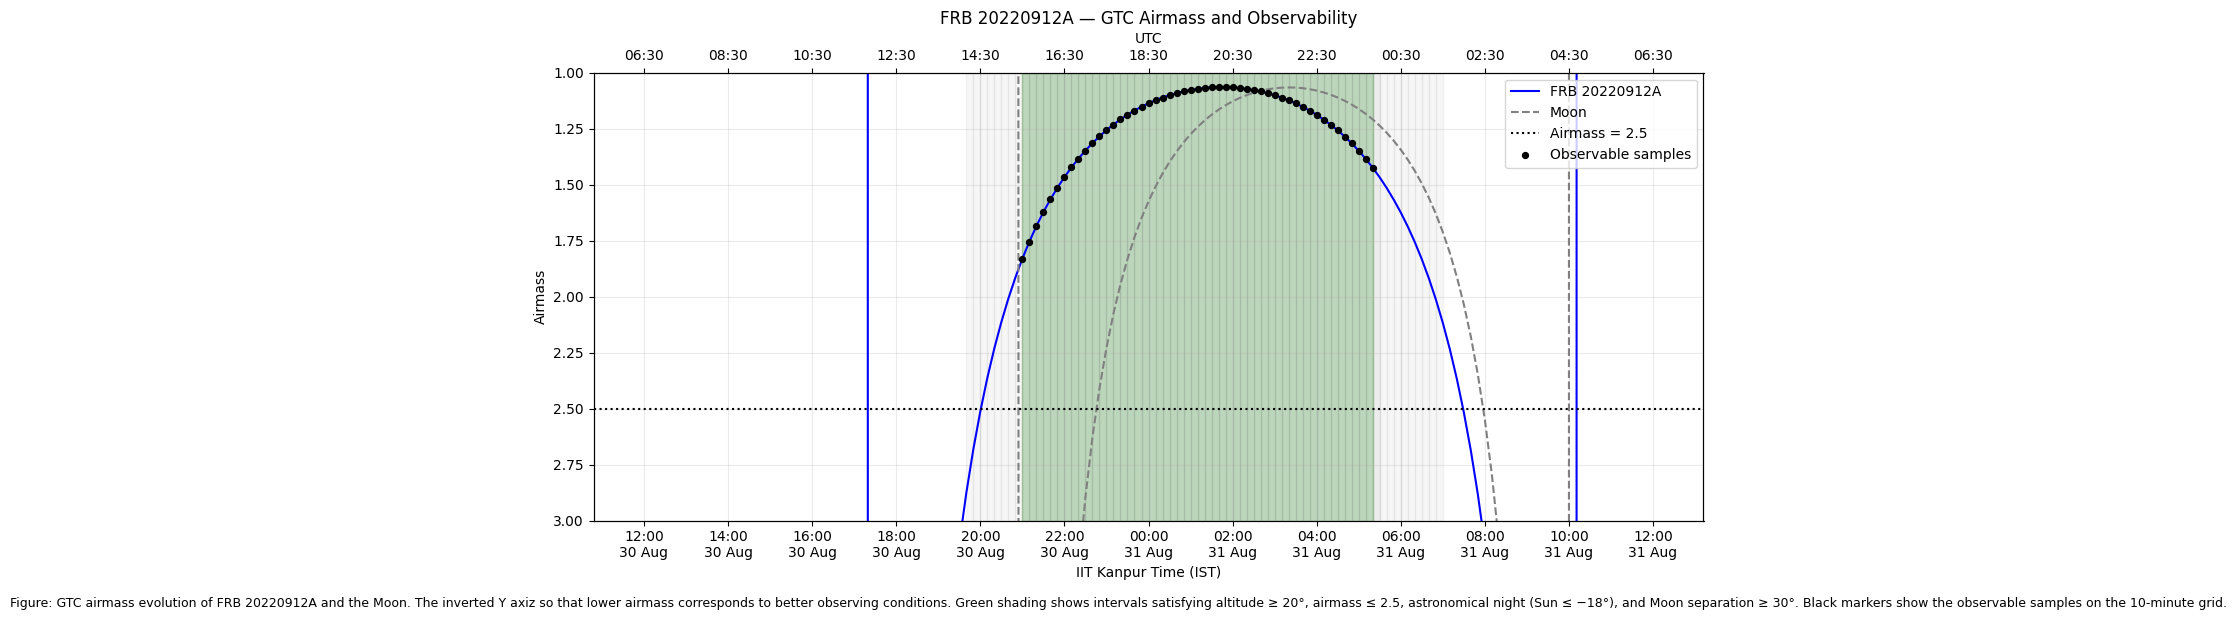

In [48]:
#plotting part
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Moon airmass
moon_altaz = moon.transform_to(
    AltAz(obstime=times, location=gtc_location)
)

moon_airmass = np.array(moon_altaz.secz, dtype=float)

# Times in datetime for plotting
from datetime import timezone, timedelta

ist = timezone(timedelta(hours=5, minutes=30))

t = times.to_datetime(timezone=ist)

fig, ax = plt.subplots(figsize=(12, 6))

# ---------------- Target and Moon ----------------

ax.plot(
    t,
    target_airmass_full,
    color="blue",
    label="FRB 20220912A"
)

ax.plot(
    t,
    moon_airmass,
    "--",
    color="gray",
    label="Moon"
)

# Airmass limit
ax.axhline(
    2.5,
    color="black",
    linestyle=":",
    label="Airmass = 2.5"
)

# ---------------- Twilight / night bands ----------------

sun_alt = sun_altaz.alt.to_value(u.deg)

# Astronomical night: Sun <= -18 deg
night = sun_alt <= -18

# Twilight: -18 < Sun <= 0
twilight = (sun_alt > -18) & (sun_alt <= 0)

# Shade contiguous regions
for i in range(len(t) - 1):

    if night[i]:
        ax.axvspan(
            t[i], t[i+1],
            color="gray",
            alpha=0.15
        )

    elif twilight[i]:
        ax.axvspan(
            t[i], t[i+1],
            color="gray",
            alpha=0.07
        )

# ---------------- Observable intervals ----------------

for start, end in windows:

    ax.axvspan(
        t[start],
        t[end],
        color="green",
        alpha=0.20
    )

# Observable 10-minute samples
observable = preferred_visibility

ax.scatter(
    t[observable],
    target_airmass_full[observable],
    color="black",
    s=18,
    zorder=5,
    label="Observable samples"
)

# ---------------- Axes ----------------

ax.set_ylim(3, 1)
ax.set_ylabel("Airmass")
ax.set_xlabel("IIT Kanpur Time (IST)")

ax.set_title(
    "FRB 20220912A — GTC Airmass and Observability"
)

# Date rollover
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M\n%d %b")
)

ax.grid(alpha=0.25)

# ---------------- UTC axis ----------------

ax_utc = ax.twiny()
ax_utc.set_xlim(ax.get_xlim())
ticks = ax.get_xticks()
ax_utc.set_xticks(ticks)
ax_utc.set_xticklabels([(mdates.num2date(x).replace(tzinfo=timezone.utc) - timedelta(hours=5, minutes=30)).strftime("%H:%M") for x in ticks])
ax_utc.set_xlabel("UTC")

# ---------------- Legend ----------------

ax.legend(loc="upper right")

# ---------------- Caption ----------------

fig.text(
    0.5,
    -0.02,
    "Figure: GTC airmass evolution of FRB 20220912A and the Moon. "
    "The inverted Y axiz so that lower airmass corresponds to "
    "better observing conditions. Green shading shows intervals satisfying "
    "altitude ≥ 20°, airmass ≤ 2.5, astronomical night (Sun ≤ −18°), "
    "and Moon separation ≥ 30°. Black markers show the observable samples "
    "on the 10-minute grid.",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "assignment_outputs/frb_20220912a_gtc_airmass.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FRB 20220912A is observable with the GTC only during the intervals where the target is above 20° altitude, has airmass ≤ 2.5, the Sun is below −18°, and the Moon is at least 30° away. Within these intervals, observations are therefore feasible under the adopted scheduling constraints.
Because the visibility calculation is sampled every 10 minutes, the exact beginning and end of an observable interval may be uncertain by up to roughly one grid interval, and short visibility windows between samples could be missed.

Two vertical blue line can be seen appearing in the plot, those are the time when the FRB passes the horizon resulting infinite value in secz.Matplotlib than connects those large which results in a straight vertical line.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [24]:
import numpy as np
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import AltAz, get_sun

# 10-minute grid covering the full UTC day
times_q19 = Time("2026-09-01 00:00:00") + np.arange(145) * 10 * u.min

# Target altitude and airmass at GTC
frb_altaz = frb_icrs.transform_to(
    AltAz(obstime=times_q19, location=gtc_location)
)

altitude = frb_altaz.alt
airmass = np.array(frb_altaz.secz, dtype=float)

# Sun altitude
sun_altaz = get_sun(times_q19).transform_to(
    AltAz(obstime=times_q19, location=gtc_location)
)

# Q19 visibility rule
visible = (
    (altitude > 0 * u.deg) &
    np.isfinite(airmass) &
    (airmass <= 2.5) &
    (sun_altaz.alt <= -18 * u.deg)
)

# Find contiguous visibility intervals
windows = []
start = None

for i in range(len(times_q19)):

    if visible[i] and start is None:
        start = i

    if start is not None and (
        i == len(times_q19) - 1 or not visible[i + 1]
    ):
        windows.append((start, i))
        start = None

# Report intervals
total_duration = 0

for start, end in windows:

    duration = (
        times_q19[end] - times_q19[start]
    ).to_value(u.hour)

    total_duration += duration

    utc_start = times_q19[start]
    utc_end = times_q19[end]

    # IIT Kanpur time = UTC + 5:30
    ist_start = utc_start + 5.5 * u.hour
    ist_end = utc_end + 5.5 * u.hour

    print("\nVisibility interval")
    print("UTC :", utc_start.isot, "to", utc_end.isot)
    print("IST :", ist_start.isot, "to", ist_end.isot)
    print("Duration:", duration, "hours")

print("\nTotal visible duration:", total_duration, "hours")


Visibility interval
UTC : 2026-09-01T00:00:00.000 to 2026-09-01T05:20:00.000
IST : 2026-09-01T05:30:00.000 to 2026-09-01T10:50:00.000
Duration: 5.333333333333333 hours

Visibility interval
UTC : 2026-09-01T21:00:00.000 to 2026-09-02T00:00:00.000
IST : 2026-09-02T02:30:00.000 to 2026-09-02T05:30:00.000
Duration: 3.0 hours

Total visible duration: 8.333333333333332 hours


For 2026-09-01, FRB 20220912A is visible from the GTC during two intervals. The first interval is 00:00–05:20 UTC (05:30–10:50 IST), lasting 5.33 h. The second interval is 21:00 UTC on September 1 to 00:00 UTC on September 2 (02:30–05:30 IST on September 2), lasting 3.00 h. Thus, the total visibility duration is approximately 8.33 h. The visibility criterion requires the source to be above the horizon, have airmass ≤ 2.5, and occur during astronomical night; no Moon constraint is applied.
the second interval crossing midnight is correctly reported as September 2 in IST. That's because IST is UTC+5:30.

## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [25]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, AltAz, get_sun
import os
import imageio.v2 as imageio
# Moderate HEALPix resolution
nside = 32
npix = hp.nside2npix(nside)

# HEALPix pixel centres
theta, phi = hp.pix2ang(nside, np.arange(npix))

ra = phi * u.rad
dec = (np.pi/2 - theta) * u.rad

sky = SkyCoord(ra=ra, dec=dec, frame="icrs")

# Weekly dates: 2026-08-30 to 2027-08-29
dates = Time("2026-08-30") + np.arange(53) * 7 * u.day

os.makedirs("assignment_outputs/gtc_frames", exist_ok=True)

frames = []

for k, date in enumerate(dates):

    # GTC AltAz transformation
    altaz = sky.transform_to(
        AltAz(obstime=date, location=gtc_location)
    )

    altitude = altaz.alt
    airmass = np.array(altaz.secz, dtype=float)

    # Sun altitude
    sun_altaz = get_sun(date).transform_to(
        AltAz(obstime=date, location=gtc_location)
    )

    # Visibility condition
    visible = (
        (altitude > 0 * u.deg) &
        np.isfinite(airmass) &
        (airmass <= 2.5) &
        (sun_altaz.alt <= -18 * u.deg)
    )

    # HEALPix map: 1 = visible, 0 = not visible
    visibility_map = visible.astype(float)

    # Plot
    fig = plt.figure(figsize=(9, 5))

    hp.mollview(
        visibility_map,
        fig=fig.number,
        title=f"GTC Observable Sky — {date.isot[:10]}",
        min=0,
        max=1,
        cbar=False,
        cmap="Greens",
        badcolor="white"
    )

    hp.graticule()

    filename = (
        f"assignment_outputs/gtc_frames/"
        f"gtc_{date.isot[:10]}.png"
    )

    plt.savefig(filename, dpi=120, bbox_inches="tight")
    plt.close()

    frames.append(imageio.imread(filename))

# Combine into GIF
imageio.mimsave(
    "assignment_outputs/gtc_visibility_year.gif",
    frames,
    duration=0.25,
    loop=0
)

print("Saved:")
print(
"assignment_outputs/gtc_visibility_year.gif")

/home/fayaz/myvenv/lib/python3.12/site-packages/healpy/visufunc.py:225: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Saved:
assignment_outputs/gtc_visibility_year.gif


AI help has been taken cosntantly throughout the assignment.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
